# Data load

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)


In [2]:
data=pd.read_csv('powerplant_data.csv')

In [3]:
data.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
data.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [6]:
x=data.drop('PE', axis=1)  # Assuming 'PE' is the target variable
y=data['PE']


In [7]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(xtrain)
xtrain_scaled = scaler.transform(xtrain)
xtest_scaled = scaler.transform(xtest)


# converting data to tensor

In [9]:
import torch
from torch import nn

torch.manual_seed(42)


In [10]:
xtrain_tensor = torch.tensor(xtrain_scaled, dtype=torch.float32)
ytrain_tensor = torch.tensor(ytrain.values, dtype=torch.float32).view(-1, 1)
xtest_tensor = torch.tensor(xtest_scaled, dtype=torch.float32)
ytest_tensor = torch.tensor(ytest.values, dtype=torch.float32).view(-1, 1)

In [11]:
#next we create a model
#our model wull have a 4 input layer and 1 output layer with 2 hidden layers of 6 neurons each like we are making athis randomly and we will see how it performs and then we will tune it to get the best performance
"""
===============================================================================
                    Artificial Neural Network (ANN)
===============================================================================

                         Input Layer
                   (4 Input Features)

      x1            x2            x3            x4
 (Temperature)   (Vacuum)    (Pressure)   (Humidity)
      ●             ●             ●             ●
       \           /|\           /|\           /
        \         / | \         / | \         /
         \       /  |  \       /  |  \       /
          \     /   |   \     /   |   \     /
           \   /    |    \   /    |    \   /
            \ /     |     \ /     |     \ /
             V      V      V      V      V

===============================================================================
                     Hidden Layer 1 (6 Neurons)
===============================================================================

           ● H1
           ● H2
           ● H3
           ● H4
           ● H5
           ● H6

(All input neurons are connected to every neuron in Hidden Layer 1)

===============================================================================
                     Hidden Layer 2 (6 Neurons)
===============================================================================

           ● H7
           ● H8
           ● H9
           ● H10
           ● H11
           ● H12

(Every neuron in Hidden Layer 1 is connected to every neuron in Hidden Layer 2)

===============================================================================
                          Output Layer
===============================================================================

                    ● ŷ (Predicted Output)

(Every neuron in Hidden Layer 2 is connected to the output neuron)

===============================================================================
Network Architecture
===============================================================================

Input Layer      : 4 Neurons
                  x1 = Temperature
                  x2 = Vacuum
                  x3 = Pressure
                  x4 = Humidity

Hidden Layer 1   : 6 Neurons
                  H1, H2, H3, H4, H5, H6

Hidden Layer 2   : 6 Neurons
                  H7, H8, H9, H10, H11, H12

Output Layer     : 1 Neuron
                  ŷ = Predicted Output

Connections       : Fully Connected
Activation        : ReLU / Sigmoid / Tanh (Hidden Layers)
Output Activation : Depends on the problem
                   - Linear (Regression)
                   - Sigmoid (Binary Classification)
                   - Softmax (Multi-class Classification)

Architecture:
4 → 6 → 6 → 1

===============================================================================
"""

'\n===============================================================================\n                    Artificial Neural Network (ANN)\n===============================================================================\n\n                         Input Layer\n                   (4 Input Features)\n\n      x1            x2            x3            x4\n (Temperature)   (Vacuum)    (Pressure)   (Humidity)\n      ●             ●             ●             ●\n       \\           /|\\           /|\\           /\n        \\         / | \\         / | \\         /\n         \\       /  |  \\       /  |  \\       /\n          \\     /   |   \\     /   |   \\     /\n           \\   /    |    \\   /    |    \\   /\n            \\ /     |     \\ /     |     \\ /\n             V      V      V      V      V\n\n===============================================================================\n                     Hidden Layer 1 (6 Neurons)\n=================================================================

# DATASET And DATALOADER Classes

In [12]:
"""
===============================================================================
                          DataLoader Class (PyTorch)
===============================================================================

                    +---------------------------+
                    |      DataLoader Class     |
                    +---------------------------+
                    |                           |
                    |  • Creates batches        |
                    |  • Shuffles data          |
                    |    (optional)             |
                    |  • Loads data            |
                    |    efficiently            |
                    |                           |
                    +---------------------------+

Purpose:
--------
The DataLoader defines how the dataset will be loaded during training.

Features:
---------
✔ Creates mini-batches automatically.
✔ Shuffles the dataset before each epoch (optional).
✔ Loads data efficiently for training.
✔ Works together with a Dataset object.

Example:
--------
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

Here,
------
dataset    -> Dataset object
batch_size -> Number of samples per batch
shuffle    -> Randomly shuffle data before each epoch

===============================================================================
"""

'\n===============================================================================\n                          DataLoader Class (PyTorch)\n===============================================================================\n\n                    +---------------------------+\n                    |      DataLoader Class     |\n                    +---------------------------+\n                    |                           |\n                    |  • Creates batches        |\n                    |  • Shuffles data          |\n                    |    (optional)             |\n                    |  • Loads data            |\n                    |    efficiently            |\n                    |                           |\n                    +---------------------------+\n\nPurpose:\n--------\nThe DataLoader defines how the dataset will be loaded during training.\n\nFeatures:\n---------\n✔ Creates mini-batches automatically.\n✔ Shuffles the dataset before each epoch (optional).\n✔ Loads 

In [13]:
"""
===============================================================================
                         TensorDataset Class (PyTorch)
===============================================================================

                    +-----------------------------+
                    |     TensorDataset Class     |
                    +-----------------------------+
                    |                             |
                    |  • Defines the dataset      |
                    |  • Provides data access     |
                    |  • Returns one sample       |
                    |    (features, target)       |
                    |                             |
                    +-----------------------------+

Purpose:
--------
The TensorDataset stores the input features and target labels together,
allowing easy access to individual samples.

Features:
---------
✔ Defines the dataset.
✔ Stores features (X) and labels (y).
✔ Returns one sample (one row) at a time.
✔ Used together with the DataLoader.

Example:
--------
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(X_train, y_train)

Here,
------
X_train -> Input features
y_train -> Target labels

Accessing Data:
---------------
features, target = train_dataset[0]

This returns:
--------------
features -> First input sample
target   -> Corresponding label

===============================================================================
"""

'\n===============================================================================\n                         TensorDataset Class (PyTorch)\n===============================================================================\n\n                    +-----------------------------+\n                    |     TensorDataset Class     |\n                    +-----------------------------+\n                    |                             |\n                    |  • Defines the dataset      |\n                    |  • Provides data access     |\n                    |  • Returns one sample       |\n                    |    (features, target)       |\n                    |                             |\n                    +-----------------------------+\n\nPurpose:\n--------\nThe TensorDataset stores the input features and target labels together,\nallowing easy access to individual samples.\n\nFeatures:\n---------\n✔ Defines the dataset.\n✔ Stores features (X) and labels (y).\n✔ Returns one sample

In [14]:
from torch.utils.data import DataLoader, TensorDataset
train_dataset = TensorDataset(xtrain_tensor, ytrain_tensor)
test_dataset = TensorDataset(xtest_tensor, ytest_tensor)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# building ann model

In [16]:
class Ann(nn.Module):
    def __init__(self):
        super(Ann,self).__init__()

        self.model = nn.Sequential(
            #1st hidden layer with 6 neurons

            nn.Linear(xtrain_tensor.shape[1], 6), 
            nn.ReLU(),

            #2nd hidden layer with 6 neurons

            nn.Linear(6, 6),
            nn.ReLU(),
            
            #output layer with 1 neuron
            nn.Linear(6, 1)
        )
    def forward(self, x):
        return self.model(x)   

In [17]:
import torch.optim as optim

model = Ann()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


# Train Model

<Axes: >

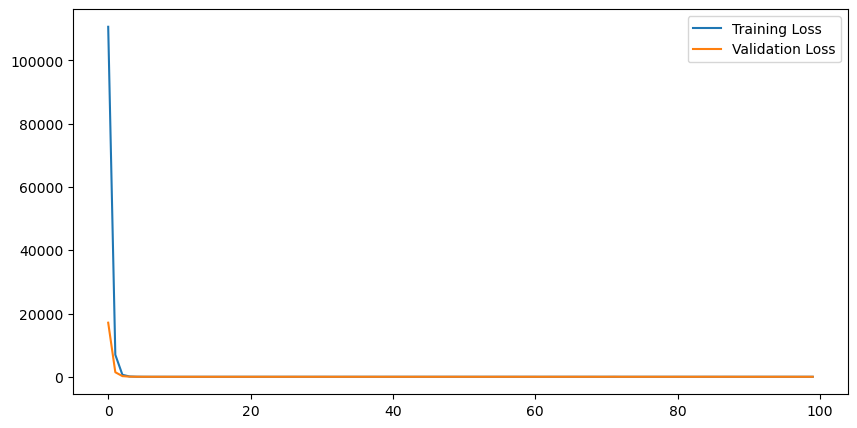

In [18]:
epochs = 100
training_loss = []
validation_loss = []
best_validation_loss = float('inf')  # Initialize best validation loss to infinity
for epoch in range(epochs):
    running_loss = 0.0
    model.train()
    for xb, yb in train_loader:
        #xb = features of 1 batch, yb = target of 1  batch
        outputs = model(xb) #pridicted output of 1 batch
        loss = criterion(outputs, yb) #loss of 1 batch
        loss.backward() #backpropagation
        optimizer.step() #update weights and biases
        running_loss += loss.item() #add loss of 1 batch to running loss
        optimizer.zero_grad() #reset gradients to 0 for next batch
    training_loss.append( running_loss / len(train_loader) ) 


    #validation
    
    running_validation_loss = 0.0
    with torch.no_grad():
        model.eval()
        for xb, yb in train_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_validation_loss += loss.item()
        epoch_validation_loss = running_validation_loss / len(train_loader)    
        validation_loss.append(running_validation_loss / len(train_loader))
        if epoch_validation_loss < best_validation_loss:
            best_validation_loss = epoch_validation_loss
            torch.save(model.state_dict(), 'best_model.pth')  # Save the model
import seaborn as sns
plt.figure(figsize=(10,5))
sns.lineplot(x=range(epochs), y=training_loss, label='Training Loss')
sns.lineplot(x=range(epochs), y=validation_loss, label='Validation Loss')        


In [19]:
model.load_state_dict(torch.load('best_model.pth'))  # Load the best model


<All keys matched successfully>

In [20]:
model.eval()
with torch.no_grad():
    train_predictions = model(xtrain_tensor)
    test_predictions = model(xtest_tensor)
    test_loss = criterion(test_predictions, ytest_tensor)
    train_loss = criterion(train_predictions, ytrain_tensor)
    print(f'Test Loss: {test_loss.item()}   Train Loss: {train_loss.item()}')

Test Loss: 19.636837005615234   Train Loss: 20.91757583618164


In [21]:
from sklearn.metrics import mean_squared_error, r2_score
print(f"r2 score is {r2_score(ytest_tensor.numpy(), test_predictions.numpy())}")

r2 score is 0.9313743114471436
